In [1]:
! pip install snntorch

     |████████████████████████████████| 95 kB 2.9 MB/s eta 0:00:011


In [2]:
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
from scipy.ndimage import maximum_filter
import os
import pandas as pd
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# parameters to perform STFT and keypoint detection
n_fft = 512
hop_length = 160
beta_a = 0.15  # Absolute threshold...higher values will yield fewer keypoints
beta_r = 0.85  # Relative threshold...higher values will yield fewer keypoints
dt, df = 4, 4  # Neighborhood size
sr = 22050
eps = 1e-4


def stft(y, sr, n_fft, hop_length, eps):
    """
        S = |STFT(y)|^2 eta power spectrogram
        log_S = log(S + eps) - log(eps) ekhane eps ekta chhoto value jate log(0) na hoy, log scale e neya hocche
        log_S = (log_S - min(log_S)) / (max(log_S) - min(log_S)) ekhane log_S ke normalize kora hocche
        eta return shape hibe (n_bins, n_frames) jekhane n_bins = n_fft // 2 + 1 and n_frames = len(y) // hop_length + 1
        ekhane n_bins holo frequency bins and n_frames holo time frames kintu actual time ar freqs onno dimension e hobe
    """
    S = np.abs(librosa.stft(y, n_fft=n_fft, hop_length=hop_length)) ** 2
    # print(f"STFT shape: {S.shape}, min: {np.min(S)}, max: {np.max(S)}")
    log_S = np.log(S + eps) - np.log(eps)
    log_S = (log_S - np.min(log_S)) / (np.max(log_S) - np.min(log_S))
    # print(f"Log-scaled STFT shape: {log_S.shape}, min: {np.min(log_S)}, max: {np.max(log_S)}")
    return log_S

def calc_keypoints(log_S, dt, df, beta_a, beta_r):

    local_max_time = maximum_filter(log_S, size=(1, 2 * dt + 1)) == log_S
    local_max_freq = maximum_filter(log_S, size=(2 * df + 1, 1)) == log_S
    keypoints = np.logical_or(local_max_time, local_max_freq)
    
    abs_mask = log_S >= beta_a
    background_mean = maximum_filter(log_S, size=(2 * df + 1, 2 * dt + 1))
    rel_mask = log_S >= beta_r * background_mean
    
    final_mask = keypoints & abs_mask & rel_mask
    return final_mask

def plotter(log_S, mask, sr, hop_length, save_path=None, filename=None, plot=True):

    freq_bins, time_bins = np.where(mask)
    times = time_bins * hop_length / sr
    freqs = freq_bins * (sr / 2) / log_S.shape[0]
    
    if plot:
        # Dual plot - STFT and keypoints
        fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
        # Plot 1: STFT
        img = librosa.display.specshow(
            log_S, sr=sr, hop_length=hop_length, x_axis="time", y_axis="linear", ax=axs[0]
        )
        axs[0].set_title("Log-Scaled STFT Spectrogram")
        fig.colorbar(img, ax=axs[0], format="%+2.0f")
        # Plot 2: Key-points only

        axs[1].scatter(times, freqs, color="red", s=10, label="Key-Points")
        axs[1].set_title("Key-Points Only")
        axs[1].set_ylabel("Frequency (Hz)")
        axs[1].set_xlabel("Time (s)")
        axs[1].legend()
        axs[1].set_ylim(0, sr // 2)
        plt.tight_layout()

        plt.tight_layout()
        plt.savefig("./test.png", dpi=150, bbox_inches='tight', pad_inches=0)
        plt.show()
    
    return times, freqs, freq_bins, time_bins


In [3]:


def process_audio(audio_path, save_path=None, filename=None, plot=True):
    """Process a single audio file through the full pipeline."""
    try:
        
        y, loaded_sr = librosa.load(audio_path, sr=sr, res_type="kaiser_fast")
        
        log_S = stft(y, loaded_sr, n_fft=n_fft, hop_length=hop_length, eps=eps)
        
        kp_mask = calc_keypoints(log_S, dt, df, beta_a, beta_r)
        
        times, freqs, freq_bins, time_bins = plotter(
            log_S, kp_mask, sr, hop_length, save_path, filename, plot
        )
        
        return {
            'times': times,
            'freqs': freqs,
            'freq_bins': freq_bins,
            'time_bins': time_bins,
            'log_S': log_S,
            'kp_mask': kp_mask
        }
    except Exception as e:
        print(f"Error processing {audio_path}: {str(e)}")
        return None



In [4]:
# load all datasets and process
dataset_path = "/kaggle/input/urbansound8k"  
output_path = "/kaggle/working"
 
# load all the sub directories in dataset_path
sub_dirs = [d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))]
# sub_dirs = sub_dirs[:2]  
# print(sub_dirs)

# load all the audio files in each sub directory, process for each sub directory and save the results in the output_path following the structure of the dataset_path
for sub_dir in sub_dirs:
    sub_dir_path = os.path.join(dataset_path, sub_dir)
    output_sub_dir = os.path.join(output_path, sub_dir)
    Path(output_sub_dir).mkdir(parents=True, exist_ok=True)
    
    audio_files = [f for f in os.listdir(sub_dir_path) if f.endswith('.wav')]
    
    for audio_file in audio_files:
        audio_path = os.path.join(sub_dir_path, audio_file)
        print(f"Processing {audio_file} in {sub_dir}...")
        result = process_audio(audio_path, save_path=output_sub_dir, filename=audio_file, plot=False)
        
        if result is not None:
            # Save the results as a numpy file
            np.save(os.path.join(output_sub_dir, f"{audio_file[:-4]}_keypoints.npy"), result)
        else:
            print(f"Failed to process {audio_file} in {sub_dir}.")
# Print completion message
print("Processing complete. All keypoints saved in the specified output directory.")



Processing 164797-2-0-8.wav in fold7...
Processing 177537-7-2-0.wav in fold7...
Processing 177729-0-0-68.wav in fold7...
Processing 6902-2-0-18.wav in fold7...
Processing 518-4-0-2.wav in fold7...
Processing 146845-0-0-2.wav in fold7...
Processing 116485-3-2-4.wav in fold7...
Processing 518-4-0-3.wav in fold7...
Processing 44737-5-0-2.wav in fold7...
Processing 201988-5-0-3.wav in fold7...
Processing 181102-9-0-50.wav in fold7...
Processing 99812-1-6-0.wav in fold7...
Processing 39857-5-0-0.wav in fold7...
Processing 61503-2-0-6.wav in fold7...
Processing 162728-1-0-0.wav in fold7...
Processing 89443-9-0-48.wav in fold7...
Processing 168846-5-1-13.wav in fold7...
Processing 149193-5-0-2.wav in fold7...
Processing 71529-4-0-2.wav in fold7...
Processing 177537-7-0-8.wav in fold7...
Processing 135527-6-4-0.wav in fold7...
Processing 146845-0-0-15.wav in fold7...
Processing 201988-5-0-12.wav in fold7...
Processing 130961-4-4-0.wav in fold7...
Processing 21683-9-0-3.wav in fold7...
Processi

In [5]:
result= process_audio("/kaggle/input/urbansound8k/fold1/101415-3-0-2.wav", plot=False)

print(result['log_S'].shape)

(257, 552)


Found 8732 valid audio files
Classes: ['air_conditioner' 'car_horn' 'children_playing' 'dog_bark' 'drilling'
 'engine_idling' 'gun_shot' 'jackhammer' 'siren' 'street_music']

=== Training Fold 1/10 ===
Epoch 1/10: Train Loss 1.6453, Train Acc 0.5436, Val Loss 1.4768, Val Acc 0.6352
Epoch 2/10: Train Loss 0.9720, Train Acc 0.8318, Val Loss 1.3427, Val Acc 0.6734
Epoch 3/10: Train Loss 0.5491, Train Acc 0.9600, Val Loss 1.5550, Val Acc 0.6584
Epoch 4/10: Train Loss 0.3292, Train Acc 0.9916, Val Loss 1.6017, Val Acc 0.6941
Epoch 5/10: Train Loss 0.2769, Train Acc 0.9973, Val Loss 1.6413, Val Acc 0.6870
Epoch 6/10: Train Loss 0.2550, Train Acc 0.9990, Val Loss 1.5604, Val Acc 0.7305
Epoch 7/10: Train Loss 0.2446, Train Acc 0.9996, Val Loss 1.7860, Val Acc 0.7127
Epoch 8/10: Train Loss 0.2405, Train Acc 0.9997, Val Loss 1.6808, Val Acc 0.7173
Epoch 9/10: Train Loss 0.2363, Train Acc 0.9997, Val Loss 1.8927, Val Acc 0.7207
Epoch 10/10: Train Loss 0.2321, Train Acc 1.0000, Val Loss 1.8219, Va

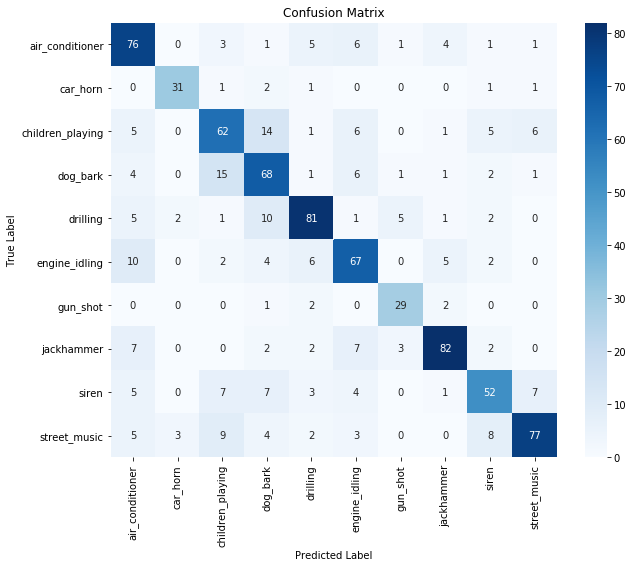


Classification Report:
                   precision    recall  f1-score   support

 air_conditioner       0.65      0.78      0.71        98
        car_horn       0.86      0.84      0.85        37
children_playing       0.62      0.62      0.62       100
        dog_bark       0.60      0.69      0.64        99
        drilling       0.78      0.75      0.76       108
   engine_idling       0.67      0.70      0.68        96
        gun_shot       0.74      0.85      0.79        34
      jackhammer       0.85      0.78      0.81       105
           siren       0.69      0.60      0.65        86
    street_music       0.83      0.69      0.75       111

        accuracy                           0.72       874
       macro avg       0.73      0.73      0.73       874
    weighted avg       0.72      0.72      0.72       874



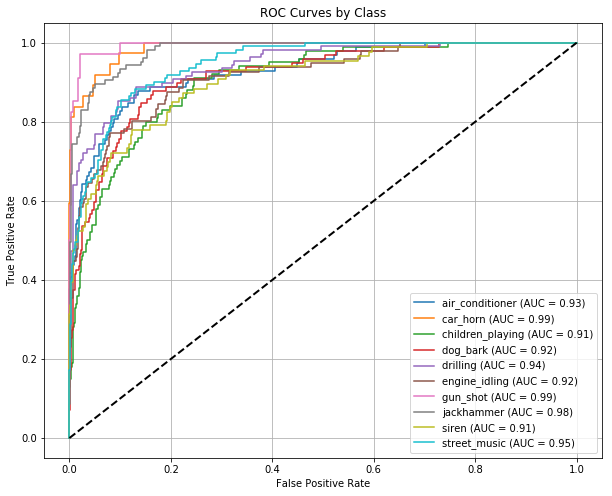


=== Training Fold 2/10 ===
Epoch 1/10: Train Loss 1.7445, Train Acc 0.4629, Val Loss 1.4337, Val Acc 0.5768
Epoch 2/10: Train Loss 1.1993, Train Acc 0.7109, Val Loss 1.4316, Val Acc 0.6339
Epoch 3/10: Train Loss 0.8624, Train Acc 0.8397, Val Loss 1.1870, Val Acc 0.7066
Epoch 4/10: Train Loss 0.5463, Train Acc 0.9319, Val Loss 1.3435, Val Acc 0.6684
Epoch 5/10: Train Loss 0.3759, Train Acc 0.9812, Val Loss 1.2305, Val Acc 0.7059
Epoch 6/10: Train Loss 0.3007, Train Acc 0.9966, Val Loss 1.3985, Val Acc 0.7018
Epoch 7/10: Train Loss 0.2588, Train Acc 0.9997, Val Loss 1.4683, Val Acc 0.7011
Epoch 8/10: Train Loss 0.2438, Train Acc 1.0000, Val Loss 1.4813, Val Acc 0.7052
Epoch 9/10: Train Loss 0.2374, Train Acc 1.0000, Val Loss 1.5345, Val Acc 0.7052
Epoch 10/10: Train Loss 0.2334, Train Acc 1.0000, Val Loss 1.5617, Val Acc 0.7195

--- Evaluation for Fold 2 ---


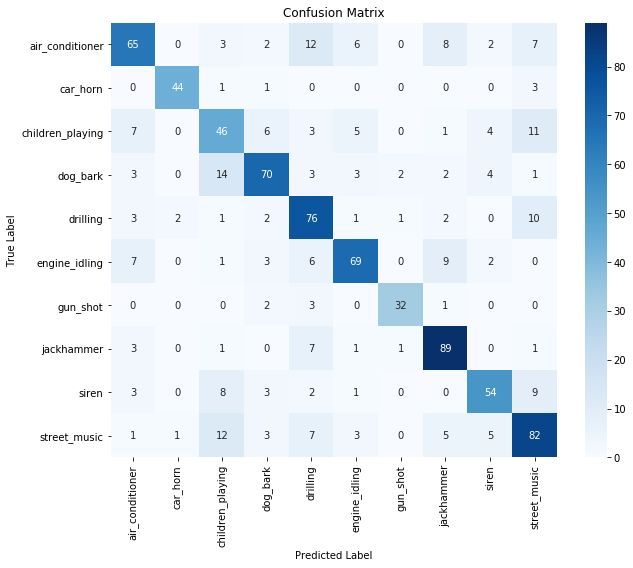


Classification Report:
                   precision    recall  f1-score   support

 air_conditioner       0.71      0.62      0.66       105
        car_horn       0.94      0.90      0.92        49
children_playing       0.53      0.55      0.54        83
        dog_bark       0.76      0.69      0.72       102
        drilling       0.64      0.78      0.70        98
   engine_idling       0.78      0.71      0.74        97
        gun_shot       0.89      0.84      0.86        38
      jackhammer       0.76      0.86      0.81       103
           siren       0.76      0.68      0.72        80
    street_music       0.66      0.69      0.67       119

        accuracy                           0.72       874
       macro avg       0.74      0.73      0.73       874
    weighted avg       0.72      0.72      0.72       874



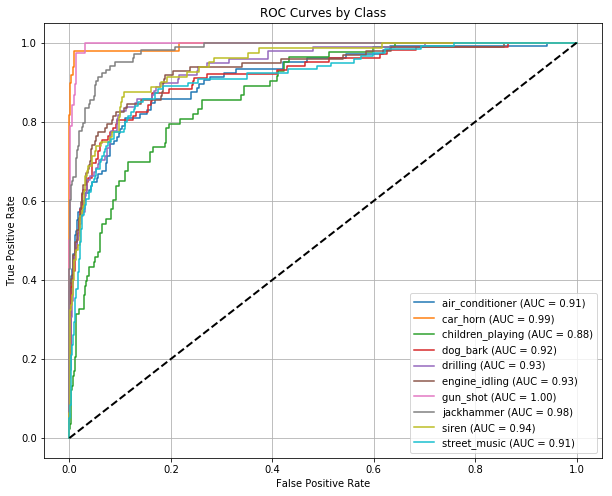


=== Training Fold 3/10 ===
Epoch 1/10: Train Loss 1.6146, Train Acc 0.5769, Val Loss 1.4149, Val Acc 0.6342
Epoch 2/10: Train Loss 0.9326, Train Acc 0.8501, Val Loss 1.2612, Val Acc 0.7021
Epoch 3/10: Train Loss 0.5461, Train Acc 0.9634, Val Loss 1.3847, Val Acc 0.6855
Epoch 4/10: Train Loss 0.3778, Train Acc 0.9873, Val Loss 1.5278, Val Acc 0.6669
Epoch 5/10: Train Loss 0.3014, Train Acc 0.9970, Val Loss 1.5585, Val Acc 0.6846
Epoch 6/10: Train Loss 0.2644, Train Acc 0.9994, Val Loss 1.5914, Val Acc 0.7030
Epoch 7/10: Train Loss 0.2483, Train Acc 0.9997, Val Loss 1.7140, Val Acc 0.6971
Epoch 8/10: Train Loss 0.2398, Train Acc 0.9999, Val Loss 1.8664, Val Acc 0.6855
Epoch 9/10: Train Loss 0.2359, Train Acc 0.9997, Val Loss 1.7100, Val Acc 0.7003
Epoch 10/10: Train Loss 0.2536, Train Acc 0.9962, Val Loss 2.3495, Val Acc 0.6235

--- Evaluation for Fold 3 ---


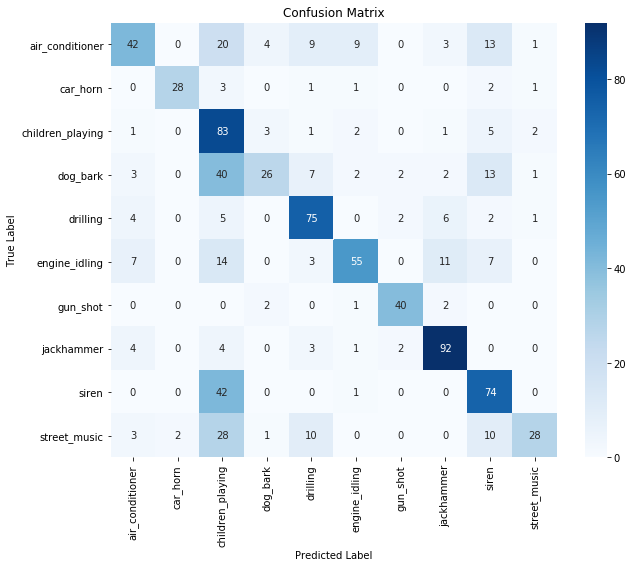


Classification Report:
                   precision    recall  f1-score   support

 air_conditioner       0.66      0.42      0.51       101
        car_horn       0.93      0.78      0.85        36
children_playing       0.35      0.85      0.49        98
        dog_bark       0.72      0.27      0.39        96
        drilling       0.69      0.79      0.74        95
   engine_idling       0.76      0.57      0.65        97
        gun_shot       0.87      0.89      0.88        45
      jackhammer       0.79      0.87      0.83       106
           siren       0.59      0.63      0.61       117
    street_music       0.82      0.34      0.48        82

        accuracy                           0.62       873
       macro avg       0.72      0.64      0.64       873
    weighted avg       0.69      0.62      0.62       873



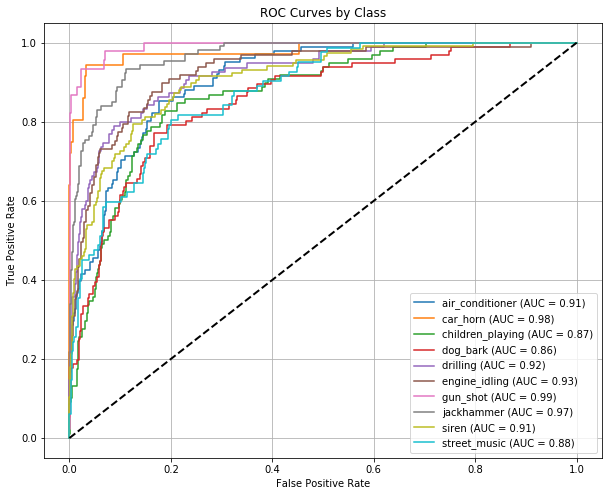


=== Training Fold 4/10 ===
Epoch 1/10: Train Loss 1.7820, Train Acc 0.4875, Val Loss 1.5174, Val Acc 0.6306
Epoch 2/10: Train Loss 1.1233, Train Acc 0.7598, Val Loss 1.2901, Val Acc 0.7069
Epoch 3/10: Train Loss 0.6563, Train Acc 0.9185, Val Loss 1.2298, Val Acc 0.7226
Epoch 4/10: Train Loss 0.3998, Train Acc 0.9802, Val Loss 1.2062, Val Acc 0.7482
Epoch 5/10: Train Loss 0.3067, Train Acc 0.9973, Val Loss 1.2497, Val Acc 0.7482
Epoch 6/10: Train Loss 0.2681, Train Acc 0.9990, Val Loss 1.2479, Val Acc 0.7537
Epoch 7/10: Train Loss 0.2545, Train Acc 0.9992, Val Loss 1.5602, Val Acc 0.7230
Epoch 8/10: Train Loss 0.2500, Train Acc 0.9990, Val Loss 1.4211, Val Acc 0.7419
Epoch 9/10: Train Loss 0.2402, Train Acc 0.9999, Val Loss 1.4762, Val Acc 0.7534
Epoch 10/10: Train Loss 0.2337, Train Acc 1.0000, Val Loss 1.5030, Val Acc 0.7578

--- Evaluation for Fold 4 ---


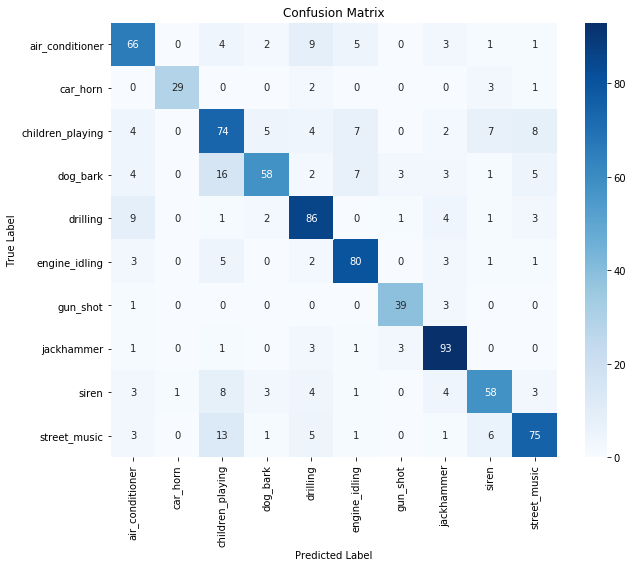


Classification Report:
                   precision    recall  f1-score   support

 air_conditioner       0.70      0.73      0.71        91
        car_horn       0.97      0.83      0.89        35
children_playing       0.61      0.67      0.64       111
        dog_bark       0.82      0.59      0.68        99
        drilling       0.74      0.80      0.77       107
   engine_idling       0.78      0.84      0.81        95
        gun_shot       0.85      0.91      0.88        43
      jackhammer       0.80      0.91      0.85       102
           siren       0.74      0.68      0.71        85
    street_music       0.77      0.71      0.74       105

        accuracy                           0.75       873
       macro avg       0.78      0.77      0.77       873
    weighted avg       0.76      0.75      0.75       873



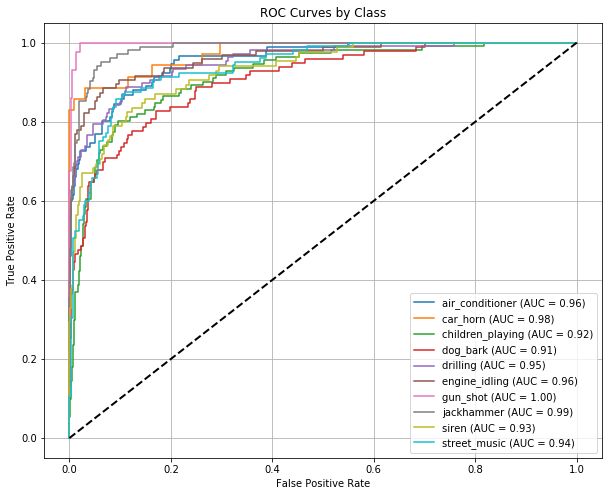


=== Training Fold 5/10 ===
Epoch 1/10: Train Loss 1.7369, Train Acc 0.4776, Val Loss 1.5251, Val Acc 0.5254
Epoch 2/10: Train Loss 1.2481, Train Acc 0.6758, Val Loss 1.2625, Val Acc 0.6617
Epoch 3/10: Train Loss 0.9257, Train Acc 0.8003, Val Loss 1.2893, Val Acc 0.6516
Epoch 4/10: Train Loss 0.7589, Train Acc 0.8624, Val Loss 1.3196, Val Acc 0.6658
Epoch 5/10: Train Loss 0.4547, Train Acc 0.9654, Val Loss 1.4120, Val Acc 0.6831
Epoch 6/10: Train Loss 0.3379, Train Acc 0.9936, Val Loss 1.3060, Val Acc 0.7107
Epoch 7/10: Train Loss 0.2878, Train Acc 0.9999, Val Loss 1.4304, Val Acc 0.7083
Epoch 8/10: Train Loss 0.2650, Train Acc 1.0000, Val Loss 1.3752, Val Acc 0.7187
Epoch 9/10: Train Loss 0.2517, Train Acc 1.0000, Val Loss 1.4470, Val Acc 0.7244
Epoch 10/10: Train Loss 0.2438, Train Acc 1.0000, Val Loss 1.6104, Val Acc 0.7130

--- Evaluation for Fold 5 ---


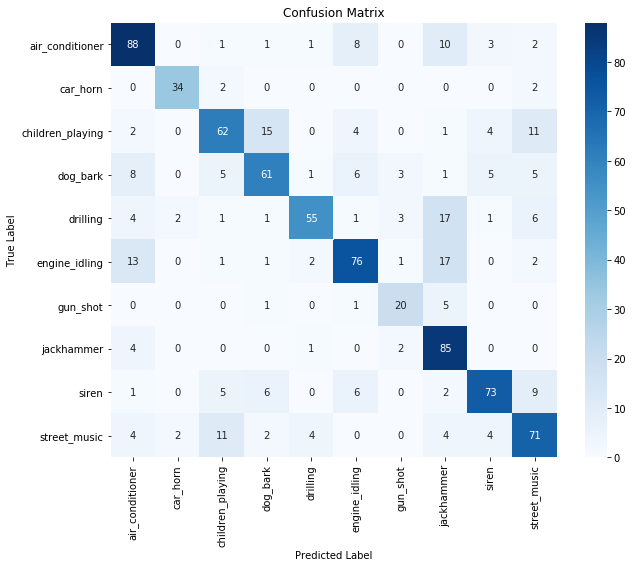


Classification Report:
                   precision    recall  f1-score   support

 air_conditioner       0.71      0.77      0.74       114
        car_horn       0.89      0.89      0.89        38
children_playing       0.70      0.63      0.66        99
        dog_bark       0.69      0.64      0.67        95
        drilling       0.86      0.60      0.71        91
   engine_idling       0.75      0.67      0.71       113
        gun_shot       0.69      0.74      0.71        27
      jackhammer       0.60      0.92      0.73        92
           siren       0.81      0.72      0.76       102
    street_music       0.66      0.70      0.68       102

        accuracy                           0.72       873
       macro avg       0.74      0.73      0.73       873
    weighted avg       0.73      0.72      0.72       873



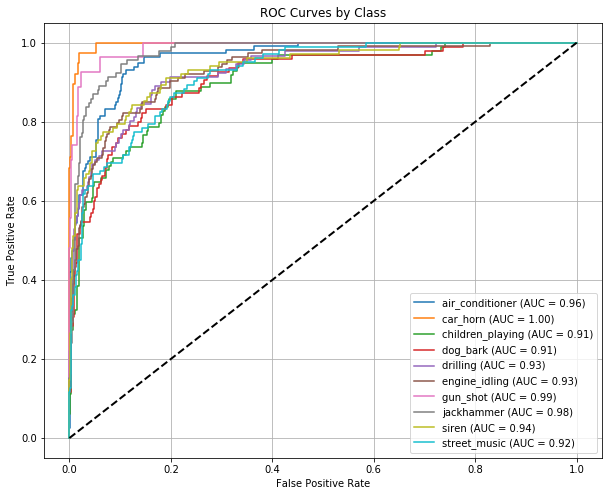


=== Training Fold 6/10 ===
Epoch 1/10: Train Loss 1.6753, Train Acc 0.5371, Val Loss 1.4407, Val Acc 0.6326
Epoch 2/10: Train Loss 0.9236, Train Acc 0.8422, Val Loss 1.3483, Val Acc 0.6739
Epoch 3/10: Train Loss 0.4852, Train Acc 0.9607, Val Loss 1.1933, Val Acc 0.7312
Epoch 4/10: Train Loss 0.3272, Train Acc 0.9924, Val Loss 1.3236, Val Acc 0.7162
Epoch 5/10: Train Loss 0.2825, Train Acc 0.9973, Val Loss 1.3576, Val Acc 0.7317
Epoch 6/10: Train Loss 0.2581, Train Acc 0.9986, Val Loss 1.4876, Val Acc 0.7448
Epoch 7/10: Train Loss 0.2520, Train Acc 0.9985, Val Loss 1.6545, Val Acc 0.7239
Epoch 8/10: Train Loss 0.2595, Train Acc 0.9970, Val Loss 1.8217, Val Acc 0.6837
Epoch 9/10: Train Loss 0.2696, Train Acc 0.9953, Val Loss 2.0025, Val Acc 0.6979
Epoch 10/10: Train Loss 0.2478, Train Acc 0.9986, Val Loss 2.1425, Val Acc 0.6476

--- Evaluation for Fold 6 ---


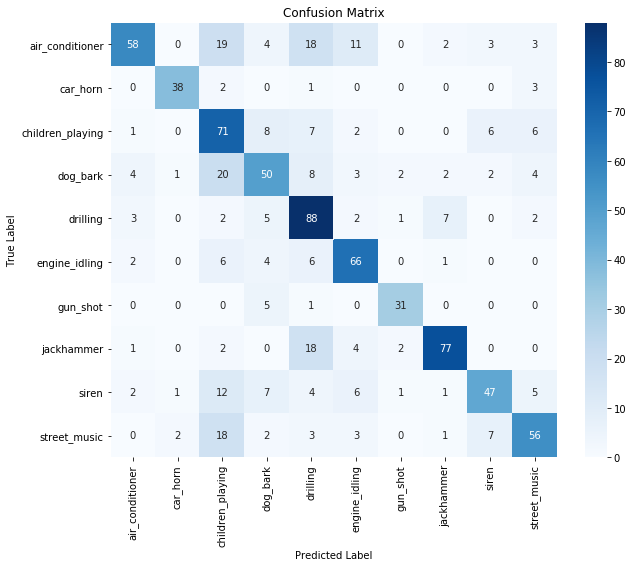


Classification Report:
                   precision    recall  f1-score   support

 air_conditioner       0.82      0.49      0.61       118
        car_horn       0.90      0.86      0.88        44
children_playing       0.47      0.70      0.56       101
        dog_bark       0.59      0.52      0.55        96
        drilling       0.57      0.80      0.67       110
   engine_idling       0.68      0.78      0.73        85
        gun_shot       0.84      0.84      0.84        37
      jackhammer       0.85      0.74      0.79       104
           siren       0.72      0.55      0.62        86
    street_music       0.71      0.61      0.65        92

        accuracy                           0.67       873
       macro avg       0.71      0.69      0.69       873
    weighted avg       0.70      0.67      0.67       873



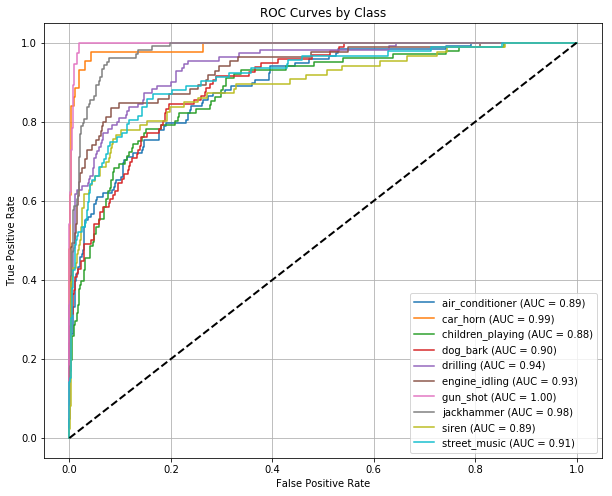


=== Training Fold 7/10 ===
Epoch 1/10: Train Loss 1.6579, Train Acc 0.5279, Val Loss 1.4188, Val Acc 0.6087
Epoch 2/10: Train Loss 1.0442, Train Acc 0.7789, Val Loss 1.2142, Val Acc 0.7000
Epoch 3/10: Train Loss 0.6772, Train Acc 0.9063, Val Loss 1.2767, Val Acc 0.6648
Epoch 4/10: Train Loss 0.4705, Train Acc 0.9610, Val Loss 1.3433, Val Acc 0.6851
Epoch 5/10: Train Loss 0.3711, Train Acc 0.9870, Val Loss 1.2847, Val Acc 0.7244
Epoch 6/10: Train Loss 0.3011, Train Acc 0.9978, Val Loss 1.3347, Val Acc 0.7216
Epoch 7/10: Train Loss 0.2701, Train Acc 0.9996, Val Loss 1.4020, Val Acc 0.7164
Epoch 8/10: Train Loss 0.2533, Train Acc 0.9997, Val Loss 1.4751, Val Acc 0.7255
Epoch 9/10: Train Loss 0.2443, Train Acc 0.9997, Val Loss 1.4852, Val Acc 0.7348
Epoch 10/10: Train Loss 0.2385, Train Acc 1.0000, Val Loss 1.4900, Val Acc 0.7309

--- Evaluation for Fold 7 ---


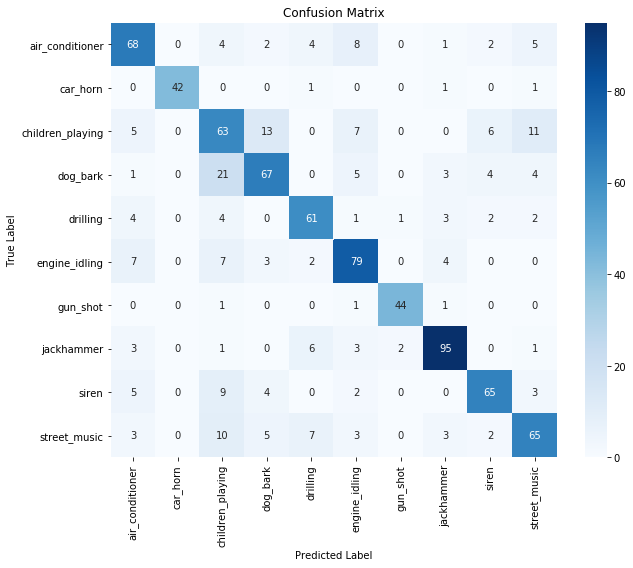


Classification Report:
                   precision    recall  f1-score   support

 air_conditioner       0.71      0.72      0.72        94
        car_horn       1.00      0.93      0.97        45
children_playing       0.53      0.60      0.56       105
        dog_bark       0.71      0.64      0.67       105
        drilling       0.75      0.78      0.77        78
   engine_idling       0.72      0.77      0.75       102
        gun_shot       0.94      0.94      0.94        47
      jackhammer       0.86      0.86      0.86       111
           siren       0.80      0.74      0.77        88
    street_music       0.71      0.66      0.68        98

        accuracy                           0.74       873
       macro avg       0.77      0.76      0.77       873
    weighted avg       0.75      0.74      0.74       873



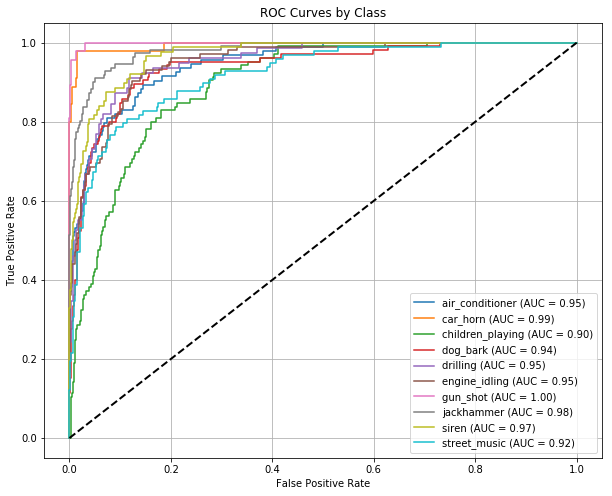


=== Training Fold 8/10 ===
Epoch 1/10: Train Loss 1.7058, Train Acc 0.4813, Val Loss 1.3220, Val Acc 0.6465
Epoch 2/10: Train Loss 0.9206, Train Acc 0.8087, Val Loss 1.2090, Val Acc 0.6869
Epoch 3/10: Train Loss 0.4420, Train Acc 0.9660, Val Loss 1.1540, Val Acc 0.7144
Epoch 4/10: Train Loss 0.2997, Train Acc 0.9973, Val Loss 1.2497, Val Acc 0.7251
Epoch 5/10: Train Loss 0.2621, Train Acc 0.9999, Val Loss 1.3270, Val Acc 0.7360
Epoch 6/10: Train Loss 0.2492, Train Acc 0.9999, Val Loss 1.3519, Val Acc 0.7453
Epoch 7/10: Train Loss 0.2414, Train Acc 1.0000, Val Loss 1.4186, Val Acc 0.7343
Epoch 8/10: Train Loss 0.2371, Train Acc 1.0000, Val Loss 1.4688, Val Acc 0.7503
Epoch 9/10: Train Loss 0.2343, Train Acc 1.0000, Val Loss 1.5164, Val Acc 0.7519
Epoch 10/10: Train Loss 0.2320, Train Acc 1.0000, Val Loss 1.5599, Val Acc 0.7403

--- Evaluation for Fold 8 ---


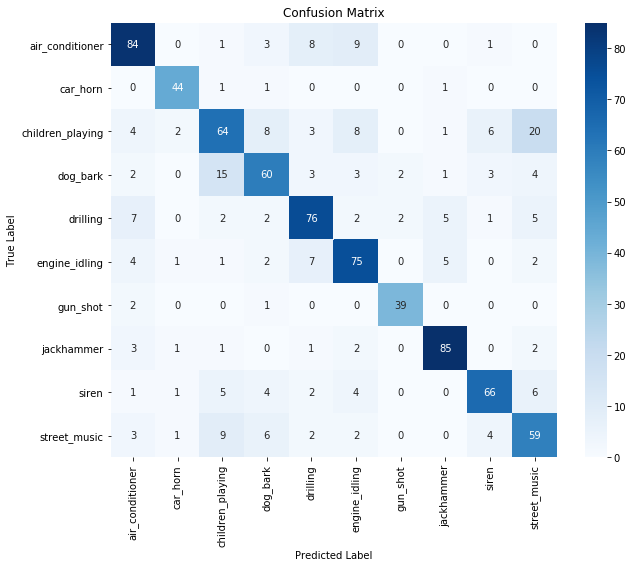


Classification Report:
                   precision    recall  f1-score   support

 air_conditioner       0.76      0.79      0.78       106
        car_horn       0.88      0.94      0.91        47
children_playing       0.65      0.55      0.60       116
        dog_bark       0.69      0.65      0.67        93
        drilling       0.75      0.75      0.75       102
   engine_idling       0.71      0.77      0.74        97
        gun_shot       0.91      0.93      0.92        42
      jackhammer       0.87      0.89      0.88        95
           siren       0.81      0.74      0.78        89
    street_music       0.60      0.69      0.64        86

        accuracy                           0.75       873
       macro avg       0.76      0.77      0.77       873
    weighted avg       0.75      0.75      0.75       873



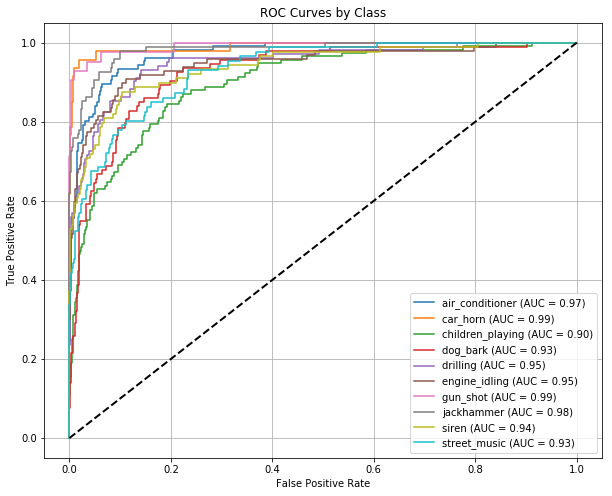


=== Training Fold 9/10 ===
Epoch 1/10: Train Loss 1.7700, Train Acc 0.4550, Val Loss 1.5746, Val Acc 0.5410
Epoch 2/10: Train Loss 1.3931, Train Acc 0.5963, Val Loss 1.4182, Val Acc 0.5535
Epoch 3/10: Train Loss 1.2070, Train Acc 0.6684, Val Loss 1.4841, Val Acc 0.5598
Epoch 4/10: Train Loss 0.9603, Train Acc 0.7773, Val Loss 1.3266, Val Acc 0.6437
Epoch 5/10: Train Loss 0.7400, Train Acc 0.8612, Val Loss 1.3175, Val Acc 0.6638
Epoch 6/10: Train Loss 0.5203, Train Acc 0.9466, Val Loss 1.3181, Val Acc 0.6797
Epoch 7/10: Train Loss 0.3605, Train Acc 0.9896, Val Loss 1.2464, Val Acc 0.7112
Epoch 8/10: Train Loss 0.2970, Train Acc 0.9985, Val Loss 1.2905, Val Acc 0.7045
Epoch 9/10: Train Loss 0.2686, Train Acc 0.9999, Val Loss 1.3035, Val Acc 0.7303
Epoch 10/10: Train Loss 0.2539, Train Acc 1.0000, Val Loss 1.4371, Val Acc 0.7264

--- Evaluation for Fold 9 ---


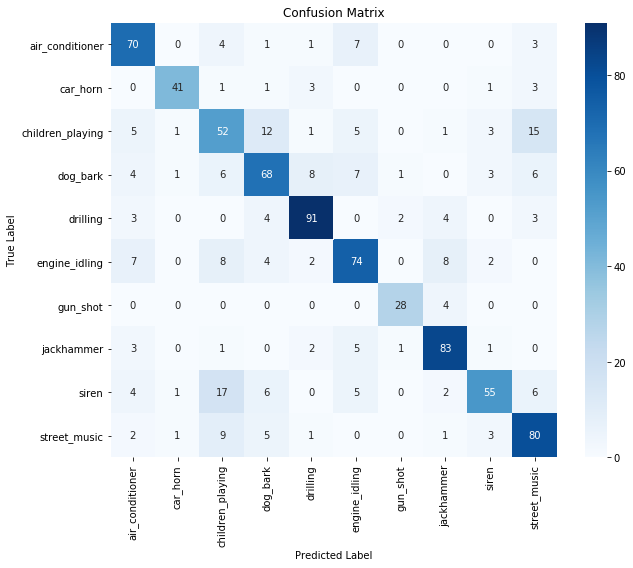


Classification Report:
                   precision    recall  f1-score   support

 air_conditioner       0.71      0.81      0.76        86
        car_horn       0.91      0.82      0.86        50
children_playing       0.53      0.55      0.54        95
        dog_bark       0.67      0.65      0.66       104
        drilling       0.83      0.85      0.84       107
   engine_idling       0.72      0.70      0.71       105
        gun_shot       0.88      0.88      0.88        32
      jackhammer       0.81      0.86      0.83        96
           siren       0.81      0.57      0.67        96
    street_music       0.69      0.78      0.73       102

        accuracy                           0.74       873
       macro avg       0.76      0.75      0.75       873
    weighted avg       0.74      0.74      0.73       873



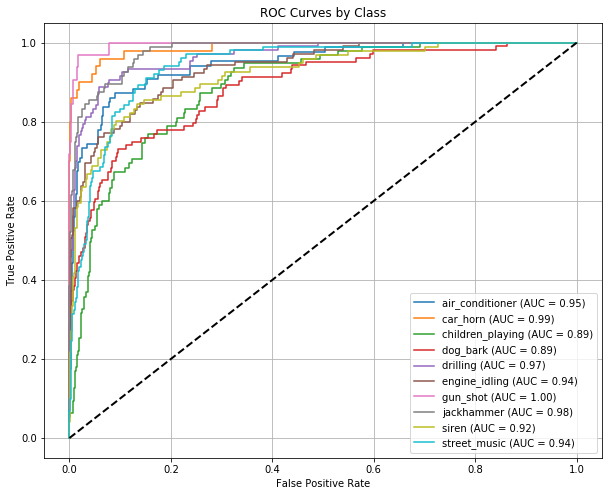


=== Training Fold 10/10 ===


In [ ]:
import torch
import torch.nn as nn
import snntorch as snn
from snntorch import surrogate
from snntorch import functional as SF
import torch.nn.functional as F
import numpy as np
import pandas as pd
import os
from sklearn.model_selection import KFold
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from collections import defaultdict
from matplotlib import pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, RocCurveDisplay
import seaborn as sns


# Custom Dataset class for UrbanSound8K keypoint data
class UrbanSound8KDataset(Dataset):
    def __init__(self, data_dir, metadata_file, transform=None):
        self.data_dir = data_dir
        self.transform = transform
        self.metadata = pd.read_csv(metadata_file)
        self.label_encoder = LabelEncoder()
        self.labels = self.label_encoder.fit_transform(self.metadata['class'].values)
        self.num_classes = len(np.unique(self.labels))
        self.file_to_data = {}
        self.valid_indices = []

        for idx, row in self.metadata.iterrows():
            filename = row['slice_file_name']
            fold_num = row['fold']
            data_path = os.path.join(data_dir, f'fold{fold_num}', filename.replace('.wav', '_keypoints.npy'))
            if os.path.exists(data_path):
                self.file_to_data[filename] = {
                    'data_path': data_path,
                    'label': self.labels[idx],
                    'class_name': row['class']
                }
                self.valid_indices.append(idx)

        print(f"Found {len(self.valid_indices)} valid audio files")
        print(f"Classes: {self.label_encoder.classes_}")

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        metadata_idx = self.valid_indices[idx]
        filename = self.metadata.iloc[metadata_idx]['slice_file_name']
        file_data = self.file_to_data[filename]
        loaded_data = np.load(file_data['data_path'], allow_pickle=True)

        if isinstance(loaded_data, dict):
            kp_mask = loaded_data['kp_mask'] if 'kp_mask' in loaded_data else loaded_data.item()['kp_mask']
        elif isinstance(loaded_data, np.ndarray) and loaded_data.dtype == 'object':
            kp_mask = loaded_data.item()['kp_mask'] if isinstance(loaded_data.item(), dict) else loaded_data
        else:
            kp_mask = loaded_data

        kp_mask = kp_mask.astype(np.float32)
        if len(kp_mask.shape) == 2:
            kp_mask = np.expand_dims(kp_mask, axis=0)

        target_width = 552
        if kp_mask.shape[-1] < target_width:
            pad_width = target_width - kp_mask.shape[-1]
            kp_mask = np.pad(kp_mask, ((0, 0), (0, 0), (0, pad_width)), mode='constant')
        elif kp_mask.shape[-1] > target_width:
            kp_mask = kp_mask[:, :, :target_width]
        elif len(kp_mask.shape) == 3 and kp_mask.shape[0] != 1:
            kp_mask = kp_mask.transpose(2, 0, 1)

        if self.transform:
            kp_mask = self.transform(kp_mask)

        return torch.FloatTensor(kp_mask), torch.LongTensor([file_data['label']])[0]

# Audio Spiking CNN Model
class AudioSpikingCNN(nn.Module):
    def __init__(self, input_shape=(1, 257, 552), num_classes=10, beta=0.95, spike_grad=surrogate.fast_sigmoid()):
        super(AudioSpikingCNN, self).__init__()
        self.num_steps = 10
        self.conv1 = nn.Conv2d(input_shape[0], 16, kernel_size=3, padding=1)
        self.lif1 = snn.Leaky(beta=beta, spike_grad=spike_grad)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.lif2 = snn.Leaky(beta=beta, spike_grad=spike_grad)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout = nn.Dropout(0.1)
        self.fc_input_size = 32 * 64 * 138
        self.fc1 = nn.Linear(self.fc_input_size, 512)
        self.lif3 = snn.Leaky(beta=beta, spike_grad=spike_grad)
        self.fc2 = nn.Linear(512, num_classes)
        self.lif4 = snn.Leaky(beta=beta, spike_grad=spike_grad)

    def forward(self, x):
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        mem3 = self.lif3.init_leaky()
        mem4 = self.lif4.init_leaky()
        spk4_rec, mem4_rec = [], []

        for step in range(self.num_steps):
            spike_input = x if step == 0 else torch.bernoulli(x * 0.8)
            cur1 = self.conv1(spike_input)
            spk1, mem1 = self.lif1(cur1, mem1)
            cur1_pooled = self.pool1(spk1)
            cur2 = self.conv2(cur1_pooled)
            spk2, mem2 = self.lif2(cur2, mem2)
            cur2_pooled = self.pool2(spk2)
            cur2_flat = self.dropout(torch.flatten(cur2_pooled, 1))
            cur3 = self.fc1(cur2_flat)
            spk3, mem3 = self.lif3(cur3, mem3)
            cur4 = self.fc2(spk3)
            spk4, mem4 = self.lif4(cur4, mem4)
            spk4_rec.append(spk4)
            mem4_rec.append(mem4)

        return torch.stack(spk4_rec, dim=0), torch.stack(mem4_rec, dim=0)


class AudioSNNTrainer:
    def __init__(self, data_dir, metadata_file, k_folds=5, epochs_per_fold=5):
        self.data_dir = data_dir
        self.metadata_file = metadata_file
        self.k_folds = k_folds
        self.epochs_per_fold = epochs_per_fold
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.dataset = UrbanSound8KDataset(data_dir, metadata_file)
        self.num_classes = self.dataset.num_classes
        self.fold_results = []

        # Prepare KFold indices
        self.kfold_splitter = KFold(n_splits=self.k_folds, shuffle=True, random_state=42)
        self.kfold_indices = list(self.kfold_splitter.split(self.dataset.valid_indices))

    def train_fold(self, fold_num):
        print(f"\n=== Training Fold {fold_num + 1}/{self.k_folds} ===")
        
        train_idx_raw, test_idx_raw = self.kfold_indices[fold_num]
    
        # These indices are relative to self.dataset.valid_indices
        train_sampler = torch.utils.data.SubsetRandomSampler(train_idx_raw)
        test_sampler = torch.utils.data.SubsetRandomSampler(test_idx_raw)
    
        train_loader = DataLoader(self.dataset, batch_size=16, sampler=train_sampler)
        test_loader = DataLoader(self.dataset, batch_size=16, sampler=test_sampler)


        model = AudioSpikingCNN(num_classes=self.num_classes).to(self.device)
        optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
        loss_fn = SF.ce_rate_loss()
        history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

        for epoch in range(self.epochs_per_fold):
            model.train()
            total_loss, total_acc = 0, 0
            for data, targets in train_loader:
                data, targets = data.to(self.device), targets.to(self.device)
                optimizer.zero_grad()
                spk_rec, mem_rec = model(data)
                loss = loss_fn(mem_rec, targets)
                loss.backward()
                optimizer.step()
                acc = SF.accuracy_rate(mem_rec, targets)
                total_loss += loss.item()
                total_acc += acc

            avg_loss = total_loss / len(train_loader)
            avg_acc = total_acc / len(train_loader)
            history['train_loss'].append(avg_loss)
            history['train_acc'].append(avg_acc)

            model.eval()
            val_loss, val_acc = 0, 0
            with torch.no_grad():
                for data, targets in test_loader:
                    data, targets = data.to(self.device), targets.to(self.device)
                    spk_rec, mem_rec = model(data)
                    loss = loss_fn(mem_rec, targets)
                    acc = SF.accuracy_rate(mem_rec, targets)
                    val_loss += loss.item()
                    val_acc += acc

            avg_val_loss = val_loss / len(test_loader)
            avg_val_acc = val_acc / len(test_loader)
            history['test_loss'].append(avg_val_loss)
            history['test_acc'].append(avg_val_acc)

            print(f"Epoch {epoch + 1}/{self.epochs_per_fold}: "
                  f"Train Loss {avg_loss:.4f}, Train Acc {avg_acc:.4f}, "
                  f"Val Loss {avg_val_loss:.4f}, Val Acc {avg_val_acc:.4f}")

        return history, avg_val_acc, model, test_loader


    def train_all_folds(self):
        all_test_accs = []
        for fold in range(self.k_folds):
            history, final_acc, model, test_loader = self.train_fold(fold)
            self.fold_results.append({
                'fold': fold + 1,
                'history': history,
                'final_accuracy': final_acc
            })
            all_test_accs.append(final_acc)
    
            print(f"\n--- Evaluation for Fold {fold + 1} ---")
            self.evaluate_model_metrics(model, test_loader)
    
        mean_acc = np.mean(all_test_accs)
        std_acc = np.std(all_test_accs)
        print(f"\n=== Cross-Validation Results ===")
        print(f"Mean Accuracy: {mean_acc:.4f} ± {std_acc:.4f}")
        return mean_acc, std_acc, self.fold_results

        
    def visualize_spike_activity(self, sample_index=0):
        model = AudioSpikingCNN(num_classes=self.num_classes).to(self.device)
        model.eval()
    
        data, target = self.dataset[sample_index]
        data = data.unsqueeze(0).to(self.device)  
    
        with torch.no_grad():
            spk_rec, mem_rec = model(data)  # Shape: [timesteps, batch, neurons]
    
        # Convert to CPU and detach
        spk_rec = spk_rec[:, 0].cpu()  # [timesteps, neurons]
        mem_rec = mem_rec[:, 0].cpu()
    
        fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
    
        axes[0].imshow(spk_rec.T, cmap='gray_r', aspect='auto')
        axes[0].set_title('Spike Activity (spk_rec)')
        axes[0].set_ylabel('Output Neurons')
        axes[0].set_xlabel('Time Step')
    
        axes[1].imshow(mem_rec.T, cmap='viridis', aspect='auto')
        axes[1].set_title('Membrane Potential (mem_rec)')
        axes[1].set_ylabel('Output Neurons')
        axes[1].set_xlabel('Time Step')
    
        plt.tight_layout()
        plt.show()

    def evaluate_model_metrics(self, fold_model, data_loader):
        all_targets = []
        all_preds = []
        all_probs = []
    
        fold_model.eval()
        with torch.no_grad():
            for data, targets in data_loader:
                data, targets = data.to(self.device), targets.to(self.device)
                _, mem_rec = fold_model(data)
                probs = mem_rec.mean(0)  # shape: [batch, num_classes]
                preds = torch.argmax(probs, dim=1)
                all_targets.extend(targets.cpu().numpy())
                all_preds.extend(preds.cpu().numpy())
                all_probs.extend(probs.cpu().numpy())
    
        all_targets = np.array(all_targets)
        all_preds = np.array(all_preds)
        all_probs = np.array(all_probs)
    
        # Confusion Matrix
        cm = confusion_matrix(all_targets, all_preds)
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=self.dataset.label_encoder.classes_, yticklabels=self.dataset.label_encoder.classes_)
        plt.xlabel("Predicted Label")
        plt.ylabel("True Label")
        plt.title("Confusion Matrix")
        plt.show()
    
        # Classification Report (includes F1-score)
        report = classification_report(all_targets, all_preds, target_names=self.dataset.label_encoder.classes_)
        print("\nClassification Report:\n", report)
    
        # ROC Curve (one-vs-rest for multiclass)
        fpr = dict()
        tpr = dict()
        roc_auc = dict()
        y_true = np.eye(self.num_classes)[all_targets]  # One-hot encode
        for i in range(self.num_classes):
            fpr[i], tpr[i], _ = roc_curve(y_true[:, i], all_probs[:, i])
            roc_auc[i] = auc(fpr[i], tpr[i])
    
        plt.figure(figsize=(10, 8))
        for i in range(self.num_classes):
            plt.plot(fpr[i], tpr[i], label=f"{self.dataset.label_encoder.classes_[i]} (AUC = {roc_auc[i]:.2f})")
    
        plt.plot([0, 1], [0, 1], "k--", lw=2)
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("ROC Curves by Class")
        plt.legend()
        plt.grid()
        plt.show()

    def plot_results(self):
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        for result in self.fold_results:
            history = result['history']
            axes[0, 0].plot(history['train_loss'], label=f"Fold {result['fold']}")
            axes[0, 1].plot(history['train_acc'], label=f"Fold {result['fold']}")
            axes[1, 0].plot(history['test_loss'], label=f"Fold {result['fold']}")
            axes[1, 1].plot(history['test_acc'], label=f"Fold {result['fold']}")

        axes[0, 0].set_title("Train Loss")
        axes[0, 1].set_title("Train Accuracy")
        axes[1, 0].set_title("Test Loss")
        axes[1, 1].set_title("Test Accuracy")
        for ax in axes.flat:
            ax.set_xlabel("Epoch")
            ax.set_ylabel("Value")
            ax.legend()
        plt.tight_layout()
        plt.show()

# Main function
def main():
    data_dir = "/kaggle/working/"
    metadata_file = "/kaggle/input/urbansound8k/UrbanSound8K.csv"
    trainer = AudioSNNTrainer(data_dir=data_dir, metadata_file=metadata_file, k_folds=10, epochs_per_fold=10)
    mean_acc, std_acc, results = trainer.train_all_folds()
    trainer.plot_results()
    return mean_acc, std_acc, results

if __name__ == "__main__":
    main()


In [ ]:
import json
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


fold_num = 1 
eval_file = f"eval_results_fold_{fold_num}.json"
with open(eval_file, 'r') as f:
    data = json.load(f)
    y_pred = data["predictions"]
    y_true = data["true_labels"]

print("Classification Report:")
print(classification_report(y_true, y_pred))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix - Fold {fold_num}")
plt.show()
